<a href="https://colab.research.google.com/github/mavalente001/planilhasmetodos/blob/main/Trabalho_de_Metodos_github.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

New names:
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`
• `` -> `...17`
• `` -> `...18`
• `` -> `...19`
• `` -> `...20`
• `` -> `...21`
• `` -> `...22`
• `` -> `...23`
• `` -> `...24`
• `` -> `...25`
• `` -> `...26`
• `` -> `...27`
• `` -> `...28`
• `` -> `...29`
• `` -> `...30`
• `` -> `...31`
• `` -> `...32`
• `` -> `...33`
• `` -> `...34`
• `` -> `...35`
• `` -> `...36`
• `` -> `...37`
• `` -> `...38`
• `` -> `...39`
• `` -> `...40`
• `` -> `...41`
• `` -> `...42`
• `` -> `...43`
• `` -> `...44`
• `` -> `...45`
• `` -> `...46`
• `` -> `...47`
• `` -> `...48`
• `` -> `...49`
• `` -> `...50`
• `` -> `...51`
• `` -> `...52`
• `` -> `...53`
• `` -> `...54`
• `` -> `...55`
• `` -> `...56`
• `` -> `...57`
• `` -> `...58`
• `` -> `...59`
• `` -> `...60`
• `` -> `...61`
• `` -> `...62`
• `` -> `...63`
• `` -> `...64`
• `` -> `...65`
• `` -> `...66`
• `` -> `...67`
• `` -> `...68`


[1] "A gerar o gráfico de densidade... Verifica a aba 'Plots' à tua direita."


[1] "========================================================================"
[1] "--- TESTE F DE HOMOGENEIDADE DAS VARIÂNCIAS ---"
[1] "========================================================================"

	F test to compare two variances

data:  Crescimento_Preco_Pct by Grupo_Poder_Compra
F = 0.97893, num df = 294, denom df = 25, p-value = 0.8766
alternative hypothesis: true ratio of variances is not equal to 1
95 percent confidence interval:
 0.5053745 1.6394713
sample estimates:
ratio of variances 
         0.9789284 



[1] "========================================================================"
[1] "--- 1. RESULTADO OFICIAL DO TESTE T (PREÇO VS PODER DE COMPRA) ---"
[1] "========================================================================"

	Welch Two Sample t-test

data:  Crescimento_Preco_Pct by Grupo_Poder_Compra
t = 1.8204, df = 29.481, p-value = 0.07887
alternative hypothesis: true di

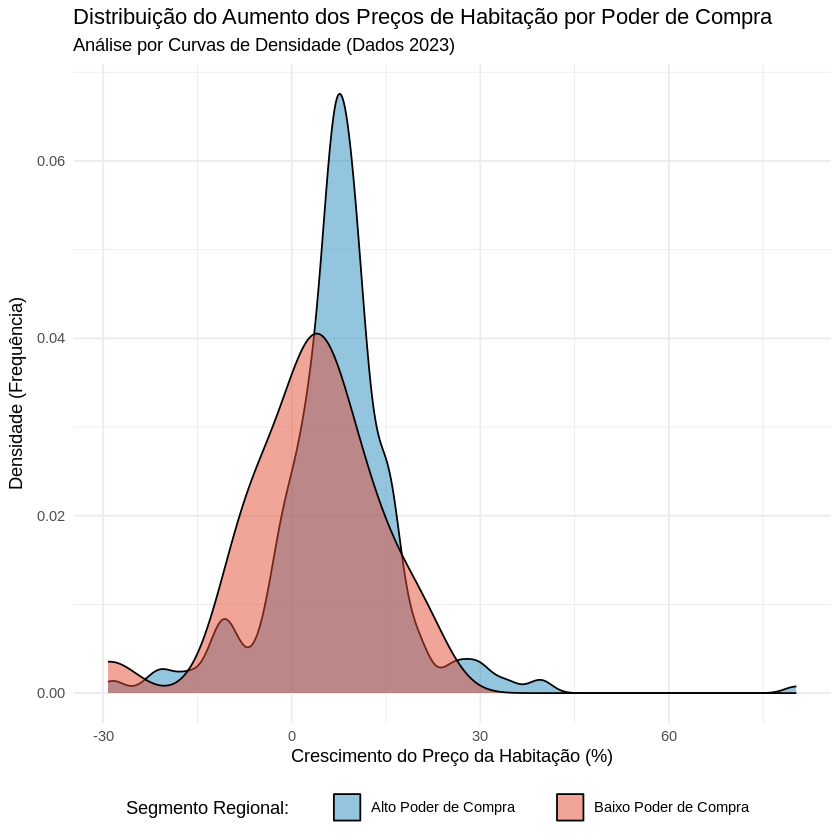

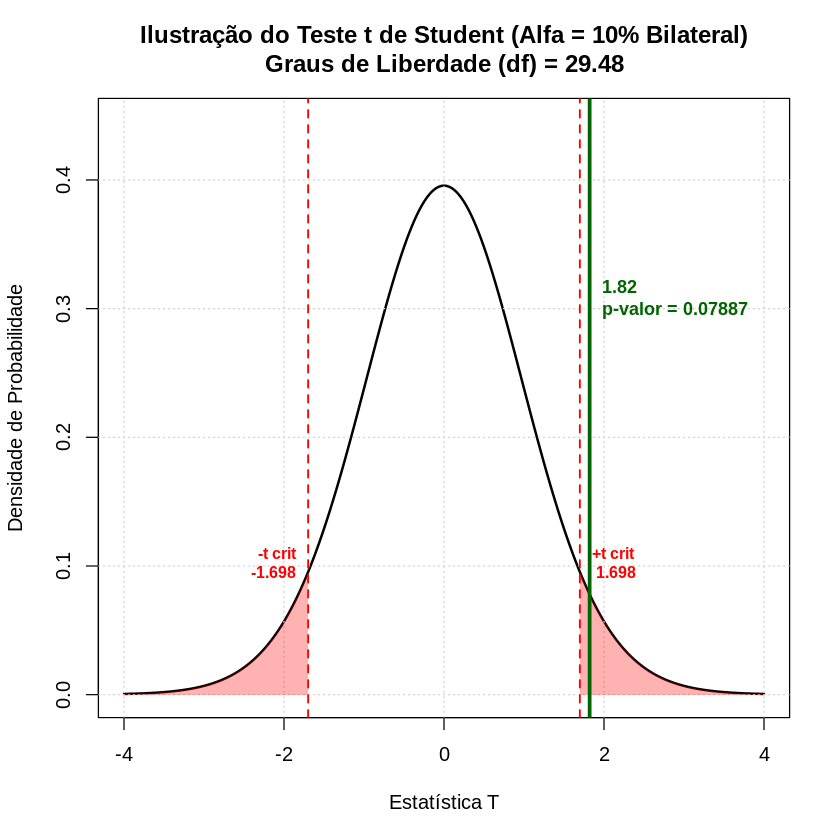

In [10]:
# ==============================================================================
# SCRIPT COMPLETO: IMPACTO DA IMIGRAÇÃO E PODER DE COMPRA NA HABITAÇÃO (2023)
# ==============================================================================
# AUTORES: Maysa Valente e Gustavo Cesar
# ==============================================================================

library(tidyverse)

# ------------------------------------------------------------------------------
# 1. DEFINIÇÃO DOS LINKS (FONTES EM FORMATO RAW DO GITHUB)
# ------------------------------------------------------------------------------
url_migracao      <- "https://raw.githubusercontent.com/mavalente001/planilhasmetodos/main/migracao%20(1).csv"
url_poder_compra  <- "https://raw.githubusercontent.com/mavalente001/planilhasmetodos/main/poderdecompra2023.csv"
url_habitacao     <- "https://raw.githubusercontent.com/mavalente001/planilhasmetodos/main/mediahabitacao2%20(2).csv"

# ------------------------------------------------------------------------------
# 2. IMPORTAÇÃO IMPLICANDO REGRAS DECIMAIS
# ------------------------------------------------------------------------------
df_migracao_bruto <- read_delim(url_migracao, delim = ",", quote = "\"",
                                locale = locale(decimal_mark = ","), show_col_types = FALSE)

df_poder_bruto    <- read_delim(url_poder_compra, delim = ",", quote = "\"",
                                locale = locale(decimal_mark = ","), show_col_types = FALSE)

df_hab_bruto      <- read_delim(url_habitacao, delim = ",", quote = "\"",
                                locale = locale(decimal_mark = ","), show_col_types = FALSE)

# ------------------------------------------------------------------------------
# 3. TRATAMENTO E LIMPEZA DE CADA BASE ISOLADA
# ------------------------------------------------------------------------------

# Base 1: Migração
df_migracao <- df_migracao_bruto %>%
  select(Local, `2023`) %>%
  rename(Fluxo_Migratorio_2023_txt = `2023`) %>%
  filter(!is.na(Local)) %>%
  mutate(
    Fluxo_Migratorio_2023 = as.numeric(str_replace(Fluxo_Migratorio_2023_txt, ",", "."))
  ) %>%
  select(Local, Fluxo_Migratorio_2023)

# Base 2: Poder de Compra
df_poder <- df_poder_bruto %>%
  select(Local, `2023`) %>%
  rename(Poder_Compra_2023 = `2023`) %>%
  filter(!is.na(Local))

# Base 3: Valores Médios de Habitação e Cálculo da Taxa de Crescimento (%)
df_habitacao <- df_hab_bruto %>%
  select(Local, `3Q_1T_2023`, `3Q_4T_2023`) %>%
  filter(!is.na(Local)) %>%
  mutate(
    V1 = as.numeric(str_replace(`3Q_1T_2023`, ",", ".")),
    V4 = as.numeric(str_replace(`3Q_4T_2023`, ",", ".")),
    Crescimento_Preco_Pct = ((V4 - V1) / V1) * 100
  ) %>%
  select(Local, Crescimento_Preco_Pct)

# ------------------------------------------------------------------------------
# 4. UNIFICAÇÃO (INNER JOIN) TRATANDO DUPLICADOS EM 'LOCAL'
# ------------------------------------------------------------------------------
df_final <- df_migracao %>%
  inner_join(df_poder, by = "Local", relationship = "many-to-many") %>%
  inner_join(df_habitacao, by = "Local", relationship = "many-to-many")

# ------------------------------------------------------------------------------
# 5. DEFINIÇÃO DO VALOR DE CORTE (MÉDIA DE PORTUGAL)
# ------------------------------------------------------------------------------
valor_corte_portugal <- df_final %>%
  filter(Local == "Portugal") %>%
  pull(Poder_Compra_2023)

if(length(valor_corte_portugal) == 0) { valor_corte_portugal <- 100 }

# ------------------------------------------------------------------------------
# 6. FILTRAGEM DE SEGURANÇA E ESTRATIFICAÇÃO DOS GRUPOS
# ------------------------------------------------------------------------------
df_analise_completa <- df_final %>%
  filter(Local != "Portugal" & Local != "Continente" & Local != "Norte") %>%
  filter(Crescimento_Preco_Pct < 100 & Crescimento_Preco_Pct > -90) %>%
  filter(!is.na(Crescimento_Preco_Pct)) %>%
  mutate(
    Grupo_Poder_Compra = ifelse(Poder_Compra_2023 >= valor_corte_portugal,
                                "Alto Poder de Compra",
                                "Baixo Poder de Compra")
  )

# ------------------------------------------------------------------------------
# 7. EMISSÃO DO GRÁFICO DE DENSIDADE (CURVA DE GAUSS)
# ------------------------------------------------------------------------------
print("A gerar o gráfico de densidade... Verifica a aba 'Plots' à tua direita.")

ggplot(df_analise_completa, aes(x = Crescimento_Preco_Pct, fill = Grupo_Poder_Compra)) +
  geom_density(alpha = 0.5) +
  scale_fill_manual(values = c("Alto Poder de Compra" = "#2b8cbe", "Baixo Poder de Compra" = "#e34a33")) +
  labs(
    title = "Distribuição do Aumento dos Preços de Habitação por Poder de Compra",
    subtitle = "Análise por Curvas de Densidade (Dados 2023)",
    x = "Crescimento do Preço da Habitação (%)",
    y = "Densidade (Frequência)",
    fill = "Segmento Regional:"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

# ==============================================================================
# 8. TESTE DE HOMOGENEIDADE DAS VARIÂNCIAS (Teste F)
# ==============================================================================

cat("\n\n")
print('========================================================================')
print('--- TESTE F DE HOMOGENEIDADE DAS VARIÂNCIAS ---')
print('========================================================================')

teste_variancia <- var.test(
  Crescimento_Preco_Pct ~ Grupo_Poder_Compra,
  data = df_analise_completa
)

print(teste_variancia)

# ==============================================================================
# 9. EXECUÇÃO DO TESTE T DE STUDENT
# ==============================================================================
cat("\n\n")
print('========================================================================')
print('--- 1. RESULTADO OFICIAL DO TESTE T (PREÇO VS PODER DE COMPRA) ---')
print('========================================================================')
teste_t_final <- t.test(Crescimento_Preco_Pct ~ Grupo_Poder_Compra, data = df_analise_completa)
print(teste_t_final)

# ------------------------------------------------------------------------------
# 10. ANÁLISE COMPLEMENTAR SINTÉTICA (TABELA DE MÉDIAS)
# ------------------------------------------------------------------------------
cat("\n\n")
print('========================================================================')
print('--- 2. ANÁLISE COMPLEMENTAR DO FLUXO MIGRATÓRIO MÉDIO POR GRUPO ---')
print('========================================================================')
analise_migratoria <- df_analise_completa %>%
  group_by(Grupo_Poder_Compra) %>%
  summarise(
    Numero_Regioes = n(),
    Media_Crescimento_Preco_Pct = mean(Crescimento_Preco_Pct),
    Media_Fluxo_Migratorio = mean(Fluxo_Migratorio_2023, na.rm = TRUE)
  )
print(analise_migratoria)


# ------------------------------------------------------------------------------
# 11. EXTRA: CORRELAÇÕES DIRETAS DA IMIGRAÇÃO
# ------------------------------------------------------------------------------
cat("\n\n")
print('========================================================================')
print('--- 3. CORRELAÇÃO DE PEARSON: IMIGRAÇÃO VS CRESCIMENTO DO PREÇO ---')
print('========================================================================')

# Teste de hipótese para H1 original (Imigração aumenta o preço?)
teste_cor_preco <- cor.test(df_analise_completa$Fluxo_Migratorio_2023,
                            df_analise_completa$Crescimento_Preco_Pct)
print(teste_cor_preco)


cat("\n\n")
print('========================================================================')
print('--- 4. CORRELAÇÃO DE PEARSON: IMIGRAÇÃO VS PODER DE COMPRA LOCAL ---')
print('========================================================================')

# Teste para perceber se os imigrantes vão mais para regiões ricas ou pobres
teste_cor_poder <- cor.test(df_analise_completa$Fluxo_Migratorio_2023,
                            df_analise_completa$Poder_Compra_2023)
print(teste_cor_poder)

# ==============================================================================
# 12. CÁLCULO DOS ERROS E PODER DO TESTE
# ==============================================================================

# 1. Extração garantida das variáveis a partir do teste T já rodado
estatistica_t   <- as.numeric(teste_t_final$statistic)
graus_liberdade <- as.numeric(teste_t_final$parameter)

# 2. Definição do Erro Tipo I (Alpha)
erro_tipo_1 <- 0.10

# 3. Cálculo do valor T crítico (Bilateral) para 10%
t_critico_calc <- qt(1 - (erro_tipo_1 / 2), df = graus_liberdade)

# 4. Cálculo do Poder do Teste
# Usamos a estatística T observada como o parâmetro de não-centralidade (ncp).
poder_teste <- (1 - pt(t_critico_calc, df = graus_liberdade, ncp = estatistica_t)) +
               pt(-t_critico_calc, df = graus_liberdade, ncp = estatistica_t)

# 5. Cálculo do Erro Tipo II (Beta)
erro_tipo_2 <- 1 - poder_teste

# Print dos resultados

cat("\n\n")
print('========================================================================')
print('--- RESULTADOS: ERRO TIPO I, ERRO TIPO II E PODER DO TESTE ---')
print('========================================================================')
cat("Erro do Tipo I (Alpha):", erro_tipo_1, "\n")
cat("Erro do Tipo II (Beta):", round(erro_tipo_2, 4), "\n")
cat("Poder do Teste (1 - Beta):", round(poder_teste, 4), "\n")
print('========================================================================')

# ==============================================================================
# PLOT DO TESTE T (ALFA = 10% BILATERAL)
# ==============================================================================

meu_t  <- teste_t_final$statistic
meu_df <- teste_t_final$parameter
meu_p  <- teste_t_final$p.value

# 2. Definição do Alfa (10% Bilateral)
alfa <- 0.10
t_critico <- qt(1 - (alfa / 2), df = meu_df)

# 3. Ajuste do eixo X (garante que o 't' apareça mesmo se for muito alto)
limite_x <- max(4, abs(meu_t) + 1)
x <- seq(-limite_x, limite_x, length.out = 1000)
y <- dt(x, df = meu_df)

# 4. Desenha a curva base da Distribuição t
plot(x, y, type = "l", lwd = 2, col = "black",
     main = paste("Ilustração do Teste t de Student (Alfa = 10% Bilateral)\nGraus de Liberdade (df) =", round(meu_df, 2)),
     xlab = "Estatística T", ylab = "Densidade de Probabilidade",
     ylim = c(0, max(y) + 0.05))
grid()

# 5. Print da Região de Rejeição Direita (5% da área)
x_dir <- x[x >= t_critico]
y_dir <- y[x >= t_critico]
polygon(c(t_critico, x_dir, max(x)), c(0, y_dir, 0), col = rgb(1, 0, 0, 0.3), border = NA)
abline(v = t_critico, col = "red", lty = 2, lwd = 1.5)

# 6. Print da Região de Rejeição Esquerda (5% da área)
x_esq <- x[x <= -t_critico]
y_esq <- y[x <= -t_critico]
polygon(c(min(x), x_esq, -t_critico), c(0, y_esq, 0), col = rgb(1, 0, 0, 0.3), border = NA)
abline(v = -t_critico, col = "red", lty = 2, lwd = 1.5)

# 7. Plot da linha do t estatístico real (Linha Verde)
abline(v = meu_t, col = "darkgreen", lty = 1, lwd = 3)

# 8. Adiciona os rótulos automáticos dos valores críticos
text(t_critico, max(y)/4, paste("+t crit\n", round(t_critico, 3)), col = "red", pos = 4, cex = 0.8, font = 2)
text(-t_critico, max(y)/4, paste("-t crit\n", -round(t_critico, 3)), col = "red", pos = 2, cex = 0.8, font = 2)

# 9. Adiciona o p-valor e t reais calculados
pos_texto <- ifelse(meu_t >= 0, 4, 2) # Evita que o texto saia do gráfico
text(meu_t, max(y) / 1.3,
     paste0(round(meu_t, 3), "\np-valor = ", format.pval(meu_p, digits = 4)),
     col = "darkgreen", pos = pos_texto, cex = 0.9, font = 2)